# MATH GR5360 Final Project — Notebook 02

Segmented strategy notebook. This notebook imports the shared engine, runs one TF sanity check, one MR sanity check, and then performs the walk-forward optimization in TF-only, MR-only, or dynamic mode.


In [2]:
MARKET_SELECT = 'TY'
QUICK_TEST = True
WALKFORWARD_MODE = 'dynamic'   # 'dynamic', 'tf', or 'mr'

In [3]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'mafn_engine').exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mafn_engine import (
    COLUMBIA_CORE,
    COLUMBIA_DIVERGING,
    COLUMBIA_NAVY,
    COLUMBIA_RED,
    COLUMBIA_WARM,
    apply_columbia_theme,
    default_mr_grid,
    default_tf_grid,
    drawdown_family,
    get_market,
    load_ohlc,
    performance_from_ledger,
    prepare_analysis_frame,
    run_backtest,
    run_diagnostics,
    run_mr_backtest,
    run_tf_backtest,
    select_modal_configuration,
    validate_ohlc,
    walk_forward,
    walk_forward_surface,
)

apply_columbia_theme()
MARKET = get_market(MARKET_SELECT)
DATA_DIR = str(PROJECT_ROOT / 'data')
print(f"Market: {MARKET.ticker} - {MARKET.name} ({MARKET.exchange})")
print(f"PV=${MARKET.PV:,}  Slippage=${MARKET.slpg}  E0=${MARKET.E0:,.0f}")

Market: TY - 10-Year Treasury (CBOT-CME)
PV=$1,000  Slippage=$18.625  E0=$100,000


In [4]:
def _grid_signature(grid: dict[str, np.ndarray]) -> tuple[tuple[str, tuple[float, ...]], ...]:
    signature = []
    for key in sorted(grid):
        values = []
        for value in np.asarray(grid[key]).tolist():
            if isinstance(value, (int, np.integer)):
                values.append(int(value))
            else:
                values.append(float(value))
        signature.append((key, tuple(values)))
    return tuple(signature)


def ensure_analysis_state(force: bool = False) -> None:
    global MARKET, full_df, analysis_df, tf_grid, mr_grid, _analysis_market

    MARKET = get_market(MARKET_SELECT)
    if force or globals().get('_analysis_market') != MARKET_SELECT or 'analysis_df' not in globals():
        full_df = load_ohlc(DATA_DIR, MARKET_SELECT, fallback_synthetic=False)
        analysis_df = prepare_analysis_frame(full_df, MARKET_SELECT)
        _analysis_market = MARKET_SELECT

    tf_grid = default_tf_grid(MARKET_SELECT, quick=QUICK_TEST)
    mr_grid = default_mr_grid(MARKET_SELECT, quick=QUICK_TEST)


def ensure_walkforward_state(force: bool = False) -> None:
    global wf_bundle, wf_params, wf_equity, wf_ledger, wf_results, _wf_signature

    ensure_analysis_state(force=force)
    signature = (
        MARKET_SELECT,
        WALKFORWARD_MODE,
        bool(QUICK_TEST),
        4,
        1,
        _grid_signature(tf_grid),
        _grid_signature(mr_grid),
    )

    if force or globals().get('_wf_signature') != signature or 'wf_bundle' not in globals():
        wf_bundle = walk_forward(
            analysis_df,
            MARKET_SELECT,
            mode=WALKFORWARD_MODE,
            tf_grid=tf_grid,
            mr_grid=mr_grid,
            T_years=4,
            tau_quarters=1,
            quick=QUICK_TEST,
            verbose=True,
        )
        _wf_signature = signature

    wf_params = wf_bundle['params']
    wf_equity = wf_bundle['equity']
    wf_ledger = wf_bundle['ledger']
    wf_results = wf_params


ensure_analysis_state(force=True)

tf_combos = len(tf_grid['L']) * len(tf_grid['S'])
mr_combos = (
    len(mr_grid['N1'])
    * len(mr_grid['N2'])
    * len(mr_grid['VolLen'])
    * len(mr_grid['MALen'])
    * len(mr_grid['StpPct'])
)
print(f"TF grid combinations: {tf_combos:,}")
print(f"MR grid combinations: {mr_combos:,}")

✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv
TF grid combinations: 50
MR grid combinations: 162


In [5]:
ensure_analysis_state()

tf_defaults = {'TY': {'L': 5000, 'S': 0.02}, 'BTC': {'L': 2000, 'S': 0.03}}
mr_defaults = {'N1': 1.0, 'N2': 0.5, 'VolLen': 48, 'MALen': 48, 'StpPct': 0.02}

tf_sanity = run_tf_backtest(analysis_df, MARKET_SELECT, **tf_defaults.get(MARKET_SELECT, {'L': 5000, 'S': 0.02}))
mr_sanity = run_mr_backtest(analysis_df, MARKET_SELECT, **mr_defaults)

sanity_summary_df = pd.DataFrame([
    {
        'Family': 'tf',
        'Profit': tf_sanity['Profit'],
        'MaxDD': tf_sanity['MaxDD'],
        'Objective': tf_sanity['Objective'],
        'Trades': tf_sanity['NumTrades'],
    },
    {
        'Family': 'mr',
        'Profit': mr_sanity['Profit'],
        'MaxDD': mr_sanity['MaxDD'],
        'Objective': mr_sanity['Objective'],
        'Trades': mr_sanity['NumTrades'],
    },
])
sanity_summary_df

,Family,Profit,MaxDD,Objective,Trades
0,tf,4.112719e+04,3.704650e+04,1.110150,207
1,mr,-4.531701e+06,4.531915e+06,-0.999953,85023


In [6]:
ensure_walkforward_state(force=True)

print()
print('WALK-FORWARD COMPLETE')
print('-' * 72)
print(f"Periods: {len(wf_params)}")
print(f"Ledger rows: {len(wf_ledger)}")
wf_params.head()

✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv
Walk-Forward [TY] mode=dynamic: IS=4yr (80,640 bars), OOS=1Q (5,040 bars)
  P1 TF IS_obj=+7.592 OOS_obj=+2.079 votes(tf=19, mr=0)
  P2 TF IS_obj=+8.640 OOS_obj=+1.045 votes(tf=20, mr=0)
  P3 TF IS_obj=+9.273 OOS_obj=+0.501 votes(tf=15, mr=0)
  P4 TF IS_obj=+9.006 OOS_obj=-0.614 votes(tf=16, mr=0)
  P5 TF IS_obj=+9.831 OOS_obj=-0.624 votes(tf=13, mr=0)
  P6 TF IS_obj=+8.669 OOS_obj=-0.799 votes(tf=11, mr=1)
  P7 TF IS_obj=+7.125 OOS_obj=+0.927 votes(tf=12, mr=0)
  P8 TF IS_obj=+6.800 OOS_obj=+0.911 votes(tf=6, mr=0)
  P9 TF IS_obj=+7.571 OOS_obj=+0.000 votes(tf=5, mr=0)
  P10 TF IS_obj=+6.134 OOS_obj=-0.921 votes(tf=4, mr=1)
  P11 TF IS_obj=+5.540 OOS_obj=+0.521 votes(tf=5, mr=0)
  P12 TF IS_obj=+5.099 OOS_obj=-0.358 votes(tf=5, mr=0)
  P13 TF IS_obj=+3.116 OOS_obj=-0.343 votes(tf=3, mr=1)
  P14 MR IS_obj=-0.999 OOS_obj=-0.975 votes(tf=0, mr=3)
  P15 MR IS_obj

,Period,Family,Mode,IS_start,IS_end,OOS_start,OOS_end,Decision_family,Decision_reason,Decision_ambiguous,...,OOS_Profit,OOS_MaxDD,OOS_Trades,L,S,N1,N2,VolLen,MALen,StpPct
0,1,tf,dynamic,1983-01-03 08:05:00,1987-06-29 12:35:00,1987-06-29 12:40:00,1987-10-08 12:30:00,tf,significant-vote majority,False,...,2697.6250,1297.6875,3,8000.0,0.01,NaN,NaN,NaN,NaN,NaN
1,2,tf,dynamic,1983-04-13 13:55:00,1987-10-08 12:30:00,1987-10-08 12:35:00,1988-01-20 12:25:00,tf,significant-vote majority,False,...,1089.9375,1042.6875,2,8000.0,0.01,NaN,NaN,NaN,NaN,NaN
2,3,tf,dynamic,1983-07-25 13:50:00,1988-01-20 12:25:00,1988-01-20 12:30:00,1988-05-02 12:20:00,tf,significant-vote majority,False,...,831.1875,1659.5000,2,8000.0,0.01,NaN,NaN,NaN,NaN,NaN
3,4,tf,dynamic,1983-11-02 13:45:00,1988-05-02 12:20:00,1988-05-02 12:25:00,1988-08-11 12:15:00,tf,significant-vote majority,False,...,-630.1250,1027.0625,1,8000.0,0.01,NaN,NaN,NaN,NaN,NaN
4,5,tf,dynamic,1984-02-14 13:40:00,1988-08-11 12:15:00,1988-08-11 12:20:00,1988-11-18 11:25:00,tf,significant-vote majority,False,...,-939.0000,1505.4375,3,5000.0,0.01,NaN,NaN,NaN,NaN,NaN


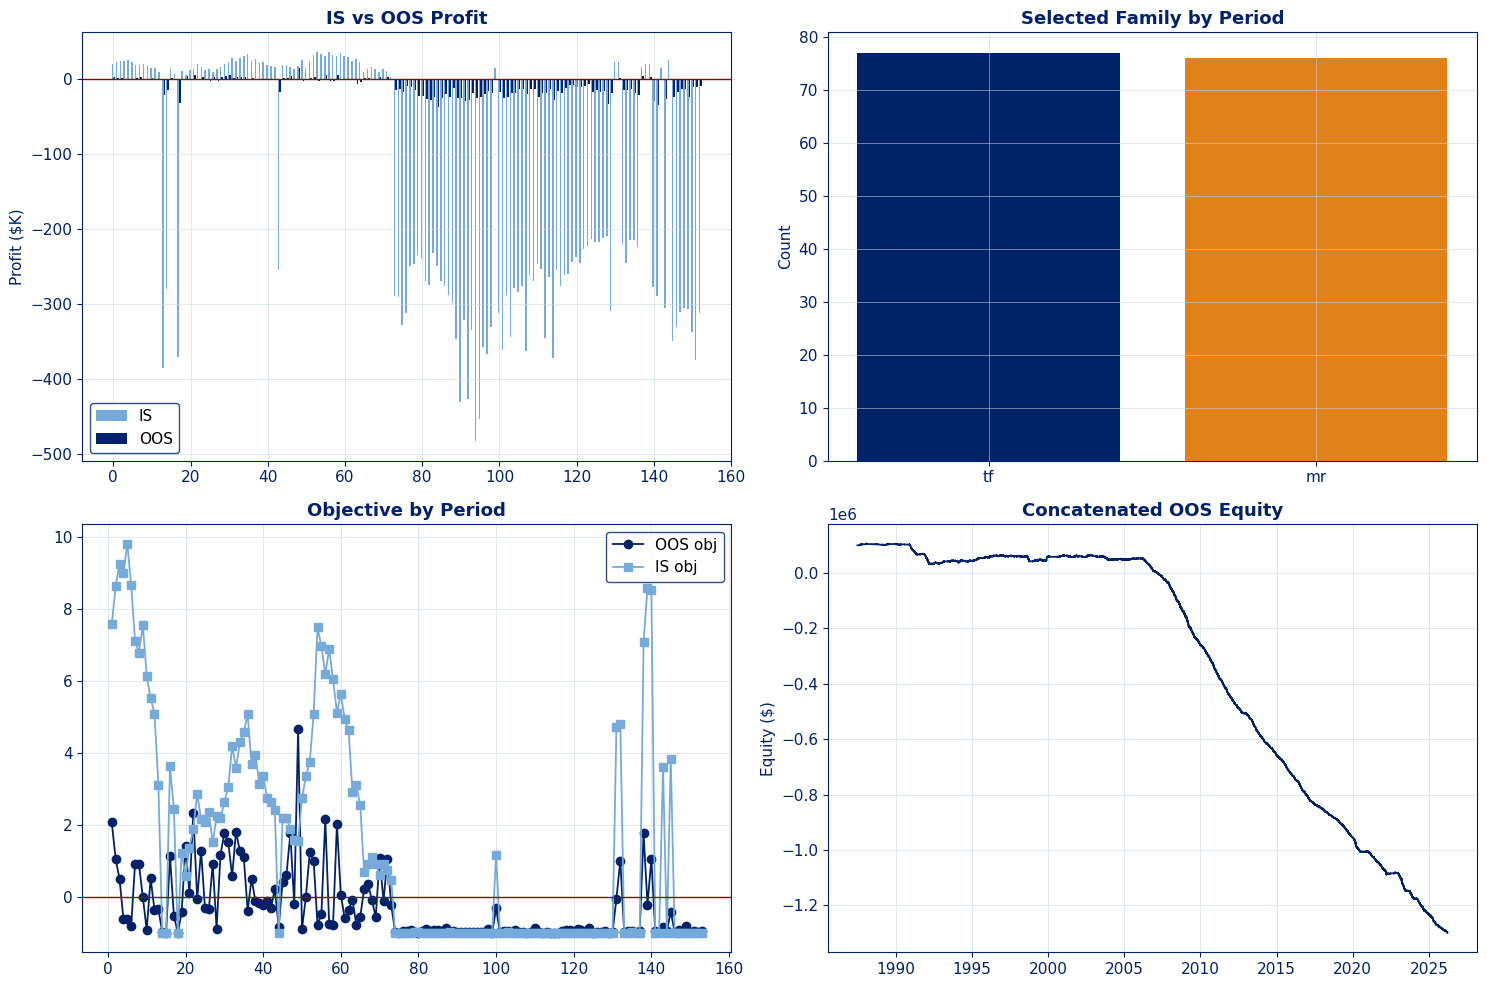

,Period,Family,Mode,IS_start,IS_end,OOS_start,OOS_end,Decision_family,Decision_reason,Decision_ambiguous,...,OOS_Profit,OOS_MaxDD,OOS_Trades,L,S,N1,N2,VolLen,MALen,StpPct
0,1,tf,dynamic,1983-01-03 08:05:00,1987-06-29 12:35:00,1987-06-29 12:40:00,1987-10-08 12:30:00,tf,significant-vote majority,False,...,2697.625000,1297.687500,3,8000.0,0.01,NaN,NaN,NaN,NaN,NaN
1,2,tf,dynamic,1983-04-13 13:55:00,1987-10-08 12:30:00,1987-10-08 12:35:00,1988-01-20 12:25:00,tf,significant-vote majority,False,...,1089.937500,1042.687500,2,8000.0,0.01,NaN,NaN,NaN,NaN,NaN
2,3,tf,dynamic,1983-07-25 13:50:00,1988-01-20 12:25:00,1988-01-20 12:30:00,1988-05-02 12:20:00,tf,significant-vote majority,False,...,831.187500,1659.500000,2,8000.0,0.01,NaN,NaN,NaN,NaN,NaN
3,4,tf,dynamic,1983-11-02 13:45:00,1988-05-02 12:20:00,1988-05-02 12:25:00,1988-08-11 12:15:00,tf,significant-vote majority,False,...,-630.125000,1027.062500,1,8000.0,0.01,NaN,NaN,NaN,NaN,NaN
4,5,tf,dynamic,1984-02-14 13:40:00,1988-08-11 12:15:00,1988-08-11 12:20:00,1988-11-18 11:25:00,tf,significant-vote majority,False,...,-939.000000,1505.437500,3,5000.0,0.01,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,149,mr,dynamic,2020-12-18 13:50:00,2024-12-13 13:45:00,2024-12-13 13:50:00,2025-03-18 13:00:00,mr,significant-vote majority,False,...,-13175.069393,16002.774298,302,NaN,NaN,1.5,1.0,80.0,80.0,0.01
149,150,mr,dynamic,2021-03-23 11:25:00,2025-03-18 13:00:00,2025-03-18 13:05:00,2025-06-17 13:35:00,mr,significant-vote majority,False,...,-23595.202138,24281.182521,271,NaN,NaN,1.5,1.0,80.0,80.0,0.01
150,151,mr,dynamic,2021-06-22 09:05:00,2025-06-17 13:35:00,2025-06-17 13:40:00,2025-09-16 11:25:00,mr,significant-vote majority,False,...,-10805.785394,11287.754001,324,NaN,NaN,1.5,1.0,48.0,80.0,0.01
151,152,mr,dynamic,2021-09-20 11:35:00,2025-09-16 11:25:00,2025-09-16 11:30:00,2025-12-15 13:40:00,mr,significant-vote majority,True,...,-10854.167503,11106.016095,362,NaN,NaN,1.5,1.0,80.0,48.0,0.01


In [7]:
ensure_walkforward_state()

if len(wf_params):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    x = np.arange(len(wf_params))

    axes[0, 0].bar(x - 0.2, wf_params['IS_Profit'] / 1000, width=0.4, color=COLUMBIA_CORE, label='IS')
    axes[0, 0].bar(x + 0.2, wf_params['OOS_Profit'] / 1000, width=0.4, color=COLUMBIA_NAVY, label='OOS')
    axes[0, 0].axhline(0.0, color=COLUMBIA_RED, linewidth=1)
    axes[0, 0].set_title('IS vs OOS Profit')
    axes[0, 0].set_ylabel('Profit ($K)')
    axes[0, 0].legend()

    fam_counts = wf_params['Family'].value_counts().reindex(['tf', 'mr']).fillna(0)
    axes[0, 1].bar(fam_counts.index, fam_counts.values, color=[COLUMBIA_NAVY, COLUMBIA_WARM])
    axes[0, 1].set_title('Selected Family by Period')
    axes[0, 1].set_ylabel('Count')

    axes[1, 0].plot(wf_params['Period'], wf_params['OOS_Objective'], marker='o', color=COLUMBIA_NAVY, label='OOS obj')
    axes[1, 0].plot(wf_params['Period'], wf_params['IS_Objective'], marker='s', color=COLUMBIA_CORE, label='IS obj')
    axes[1, 0].axhline(0.0, color=COLUMBIA_RED, linewidth=1)
    axes[1, 0].set_title('Objective by Period')
    axes[1, 0].legend(loc='best')

    if len(wf_equity):
        axes[1, 1].plot(wf_equity.index, wf_equity['OOS_Equity'], color=COLUMBIA_NAVY)
        axes[1, 1].set_title('Concatenated OOS Equity')
        axes[1, 1].set_ylabel('Equity ($)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No OOS equity generated', ha='center', va='center')
        axes[1, 1].set_axis_off()

    plt.tight_layout()
    plt.show()

wf_params

In [8]:
ensure_walkforward_state()

if len(wf_ledger):
    print()
    print('OOS TRADE LEDGER PREVIEW')
    print('-' * 72)
    wf_ledger.head(20)
else:
    print('No OOS trades generated.')


OOS TRADE LEDGER PREVIEW
------------------------------------------------------------------------
